In [1]:
import pandas as pd
import glob
import os

In [2]:
# Merge NTW 21533

In [3]:
keep_cols_outbound = ['N° de voyage', 'PTF départ.1', 'PTF arrivée.1', 'Date/heure départ du segment', 'N° DC', 'Nb UM', 'Colis', 'Réalisé le', "Donneur d'ordre"]

In [4]:
folder_path = "/Users/guelbi/Desktop/explore/gr-forecast-ds-master/NTW-21533"

csv_files = glob.glob(os.path.join(folder_path, "*.csv"))

dfs = []
for f in csv_files:
    df = pd.read_csv(f, usecols=keep_cols_outbound, sep="|", encoding="ISO-8859-1")  # only read selected columns
    dfs.append(df)

combined = pd.concat(dfs, ignore_index=True)

/var/folders/kz/2wc2rwt172q17drv43vy56cr0000gn/T/ipykernel_89725/561757012.py:7: DtypeWarning: Columns (17) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f, usecols=keep_cols_outbound, sep="|", encoding="ISO-8859-1")  # only read selected columns
/var/folders/kz/2wc2rwt172q17drv43vy56cr0000gn/T/ipykernel_89725/561757012.py:7: DtypeWarning: Columns (17) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f, usecols=keep_cols_outbound, sep="|", encoding="ISO-8859-1")  # only read selected columns
/var/folders/kz/2wc2rwt172q17drv43vy56cr0000gn/T/ipykernel_89725/561757012.py:7: DtypeWarning: Columns (17) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f, usecols=keep_cols_outbound, sep="|", encoding="ISO-8859-1")  # only read selected columns
/var/folders/kz/2wc2rwt172q17drv43vy56cr0000gn/T/ipykernel_89725/561757012.py:7: DtypeWarning: Columns (17) have mixed

In [5]:
combined['PTF départ.1'].value_counts()

PTF départ.1
LYON        1700494
WARSZAWA    1363161
GENNEVIL    1083880
POZNAN      1010399
MOISSY       916466
             ...   
LUTON            93
CHIASSO          67
CORBAS           65
VILNIUS          32
AMSTERDA         17
Name: count, Length: 85, dtype: int64

In [6]:
combined = combined[combined['PTF départ.1']=='GENNEVIL']

In [7]:
combined.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1083880 entries, 246 to 20262634
Data columns (total 9 columns):
 #   Column                        Non-Null Count    Dtype  
---  ------                        --------------    -----  
 0   N° de voyage                  1083880 non-null  object 
 1   PTF départ.1                  1083880 non-null  object 
 2   PTF arrivée.1                 1083879 non-null  object 
 3   Date/heure départ du segment  1083880 non-null  object 
 4   N° DC                         1083880 non-null  object 
 5   Nb UM                         1083880 non-null  float64
 6   Donneur d'ordre               1083863 non-null  object 
 7   Colis                         1083853 non-null  object 
 8   Réalisé le                    1083871 non-null  object 
dtypes: float64(1), object(8)
memory usage: 82.7+ MB


In [1]:
# Ensure the date column is datetime
combined['Réalisé le'] = pd.to_datetime(combined['Réalisé le'], dayfirst=True, errors='coerce')
combined['Date/heure départ du segment'] = pd.to_datetime(combined['Date/heure départ du segment'], dayfirst=True, errors='coerce')

combined["date_all"] = combined["Réalisé le"].fillna(combined['Date/heure départ du segment'])
# Sort so the earliest date per package comes first
df_sorted = combined.sort_values(['N° DC', 'date_all'], ascending=[True, True])
#df_sorted = combined.sort_values(['N° DC', 'Réalisé le'], ascending=[True, True])

# Keep the first occurrence per package
combined = df_sorted.drop_duplicates(subset='N° DC', keep='first')

NameError: name 'pd' is not defined

In [9]:
voyage_col = "N° de voyage"  
voyage_agg = (
    combined.groupby(voyage_col, as_index=False)
      .agg(
          earliest_ts=("date_all", "min"),   # earliest timestamp for the voyage
          total_nb_um=("Nb UM", "sum")       # total packages across all voyage rows
      )
)

voyage_agg["warehouse_day"] = (voyage_agg["earliest_ts"] - pd.Timedelta(hours=5)).dt.floor("D")

In [10]:
voyage_agg.to_csv('checkwith.csv',index=False)

In [11]:
voyage_agg.head()

,N° de voyage,earliest_ts,total_nb_um,warehouse_day
0,T0012390357,2024-06-10 17:40:00,33.0,2024-06-10
1,T0012390675,2024-06-08 03:30:00,137.0,2024-06-07
2,T0012391192,2024-06-18 04:37:53,1.0,2024-06-17
3,T0012391259,2024-06-10 12:53:00,87.0,2024-06-10
4,T0012391283,2024-06-10 22:42:00,107.0,2024-06-10


In [12]:
voyage_agg[voyage_agg['warehouse_day']=='2025-05-08']

,N° de voyage,earliest_ts,total_nb_um,warehouse_day
9352,T0012435830,2025-05-09 00:31:00,140.0,2025-05-08
9359,T0012435913,2025-05-09 02:39:00,61.0,2025-05-08
9360,T0012435922,2025-05-09 02:19:00,134.0,2025-05-08
9362,T0012435942,2025-05-09 00:37:00,54.0,2025-05-08
9364,T0012435963,2025-05-09 03:06:00,58.0,2025-05-08
9365,T0012435964,2025-05-09 04:20:00,19.0,2025-05-08
9366,T0012435970,2025-05-09 04:24:00,83.0,2025-05-08
17679,T5142639390,2025-05-09 04:12:00,14.0,2025-05-08


In [13]:
date_col = "warehouse_day"
count_col = "total_nb_um"

day = voyage_agg[date_col].dt.date   # returns Python date objects
# Alternatively: day = df[date_col].dt.floor("D")  # keeps pandas datetime midnight

voyage_agg[count_col] = pd.to_numeric(voyage_agg[count_col], errors="coerce")

df_clean = voyage_agg.dropna(subset=[date_col, count_col])

# 4) Group by day and sum
daily_packages_25 = (
    df_clean
    .groupby(day)[count_col]
    .sum()
    .sort_index()
)

In [14]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17853 entries, 0 to 17852
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   N° de voyage   17853 non-null  object        
 1   earliest_ts    17853 non-null  datetime64[ns]
 2   total_nb_um    17853 non-null  float64       
 3   warehouse_day  17853 non-null  datetime64[ns]
dtypes: datetime64[ns](2), float64(1), object(1)
memory usage: 558.0+ KB


In [15]:
combined.isna().sum()

N° de voyage                        0
PTF départ.1                        0
PTF arrivée.1                       1
Date/heure départ du segment        0
N° DC                               0
Nb UM                               0
Donneur d'ordre                     8
Colis                               2
Réalisé le                      10181
date_all                            0
dtype: int64

In [16]:

import pandas as pd

s = daily_packages_25.copy()
s.index = pd.to_datetime(s.index)
s = s.sort_index()   # ensure chronological order

# ---- Fold Saturdays: add to previous row ----
sat_mask = s.index.dayofweek == 5    # Saturdays
sat_positions = [s.index.get_loc(d) for d in s.index[sat_mask]]

for pos in sat_positions:
    if pos > 0:  # ensure there *is* a previous row
        s.iloc[pos - 1] += s.iloc[pos]   # add Saturday to previous row

# remove Saturdays
s = s[~sat_mask]

# ---- Fold Sundays: add to next row ----
sun_mask = s.index.dayofweek == 6    # Sundays
sun_positions = [s.index.get_loc(d) for d in s.index[sun_mask]]

# careful: iterate in reverse so shifting index doesn't affect upcoming positions
for pos in reversed(sun_positions):
    if pos < len(s) - 1:  # ensure there is a next row
        s.iloc[pos + 1] += s.iloc[pos]   # add Sunday to next row

# remove Sundays
s = s[~sun_mask]

## final sorted series
daily_packages_25 = s.sort_index(ascending=False)



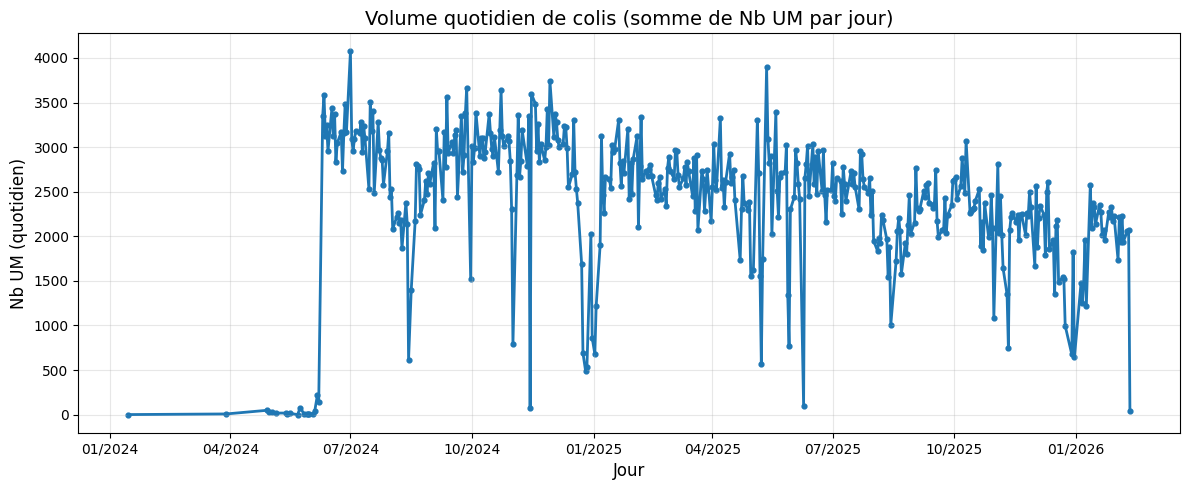

In [17]:
import matplotlib.pyplot as plt
from matplotlib.dates import AutoDateLocator, AutoDateFormatter

# -------------------------
# Tracé du graphique
# -------------------------
plt.figure(figsize=(12, 5))

# Courbe
plt.plot(daily_packages_25.index, daily_packages_25.values, color="#1f77b4", linewidth=2)

# Titre et axes (en français)
plt.title("Volume quotidien de colis (somme de Nb UM par jour)", fontsize=14)
plt.xlabel("Jour", fontsize=12)
plt.ylabel("Nb UM (quotidien)", fontsize=12)

# Mise en forme des dates sur l’axe X
locator = AutoDateLocator()
formatter = AutoDateFormatter(locator)
formatter.scaled[1.0] = "%d/%m/%Y"     # jours
formatter.scaled[30.0] = "%m/%Y"       # mois
formatter.scaled[365.0] = "%Y"         # années

ax = plt.gca()
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(formatter)
plt.grid(True, alpha=0.3)

# Option: points sur la courbe pour faciliter la lecture
plt.scatter(daily_packages_25.index, daily_packages_25.values, color="#1f77b4", s=12)

plt.tight_layout()



In [17]:
# Merge NTW 18703

In [11]:
keep_cols_18 = ['N° de voyage', 'PTF départ.1', 'PTF arrivée.1', 'Date/heure départ du segment', 'N° DC', 'Nb UM']

In [12]:
folder_path = "/Users/guelbi/Desktop/explore/gr-forecast-ds-master/NTW-18703"

csv_files = glob.glob(os.path.join(folder_path, "*.csv"))

dfs = []
for f in csv_files:
    df = pd.read_csv(f, usecols=keep_cols_18, sep="|", encoding="ISO-8859-1", on_bad_lines='skip', engine='python')  # only read selected columns
    dfs.append(df)

combined = pd.concat(dfs, ignore_index=True)

In [13]:
combined['PTF départ.1'].value_counts()

PTF départ.1
LYON                   1364066
GENNEVIL                952378
DIJON                   716012
MOISSY                  711579
TOULOUSE                695007
                        ...   
LISBOA                       1
20/11/2023 21:11:17          1
08/02/2024 12:01:45          1
19/01/2024 07:48:37          1
20/12/2023 07:04:18          1
Name: count, Length: 94, dtype: int64

In [20]:
combined = combined[combined['PTF départ.1']=='GENNEVIL']

In [21]:
combined.info()

<class 'pandas.core.frame.DataFrame'>
Index: 952378 entries, 100 to 12588379
Data columns (total 6 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   N° de voyage                  952378 non-null  object 
 1   PTF départ.1                  952378 non-null  object 
 2   PTF arrivée.1                 952376 non-null  object 
 3   Date/heure départ du segment  952378 non-null  object 
 4   N° DC                         952378 non-null  object 
 5   Nb UM                         952378 non-null  float64
dtypes: float64(1), object(5)
memory usage: 50.9+ MB


In [22]:
combined['Date/heure départ du segment'] = pd.to_datetime(combined['Date/heure départ du segment'], dayfirst=True, errors='coerce')
# Sort so the earliest date per package comes first
df_sorted = combined.sort_values(['N° DC', 'Date/heure départ du segment'], ascending=[True, True])
# Keep the first occurrence per package
combined = df_sorted.drop_duplicates(subset='N° DC', keep='first')

In [23]:
voyage_col = "N° de voyage"  
voyage_agg_18 = (
    combined.groupby(voyage_col, as_index=False)
    .agg(
          earliest_ts=("Date/heure départ du segment", "min"),   # earliest timestamp for the voyage
          total_nb_um=("Nb UM", "sum")       # total packages across all voyage rows
      )
)

voyage_agg_18["warehouse_day"] = (voyage_agg_18["earliest_ts"] - pd.Timedelta(hours=5)).dt.floor("D")

In [24]:
voyage_agg_18.head()

,N° de voyage,earliest_ts,total_nb_um,warehouse_day
0,T0012339186,2023-08-10 17:30:13,150.0,2023-08-10
1,T0012341500,2023-07-28 12:38:51,1.0,2023-07-28
2,T0012341508,2023-07-28 19:10:41,100.0,2023-07-28
3,T0012341509,2023-07-29 00:04:41,66.0,2023-07-28
4,T0012341512,2023-07-28 19:58:21,94.0,2023-07-28


In [25]:
date_col = "warehouse_day"
count_col = "total_nb_um"

day = voyage_agg_18[date_col].dt.date   # returns Python date objects
# Alternatively: day = df[date_col].dt.floor("D")  # keeps pandas datetime midnight

voyage_agg_18[count_col] = pd.to_numeric(voyage_agg_18[count_col], errors="coerce")

df_clean = voyage_agg_18.dropna(subset=[date_col, count_col])

# 4) Group by day and sum
daily_packages_18 = (
    df_clean
    .groupby(day)[count_col]
    .sum()
    .sort_index()
)

In [26]:

import pandas as pd

s = daily_packages_18.copy()
s.index = pd.to_datetime(s.index)
s = s.sort_index()   # ensure chronological order

# ---- Fold Saturdays: add to previous row ----
sat_mask = s.index.dayofweek == 5    # Saturdays
sat_positions = [s.index.get_loc(d) for d in s.index[sat_mask]]

for pos in sat_positions:
    if pos > 0:  # ensure there *is* a previous row
        s.iloc[pos - 1] += s.iloc[pos]   # add Saturday to previous row

# remove Saturdays
s = s[~sat_mask]

# ---- Fold Sundays: add to next row ----
sun_mask = s.index.dayofweek == 6    # Sundays
sun_positions = [s.index.get_loc(d) for d in s.index[sun_mask]]

# careful: iterate in reverse so shifting index doesn't affect upcoming positions
for pos in reversed(sun_positions):
    if pos < len(s) - 1:  # ensure there is a next row
        s.iloc[pos + 1] += s.iloc[pos]   # add Sunday to next row

# remove Sundays
s = s[~sun_mask]

## final sorted series
daily_packages_18 = s.sort_index(ascending=False)



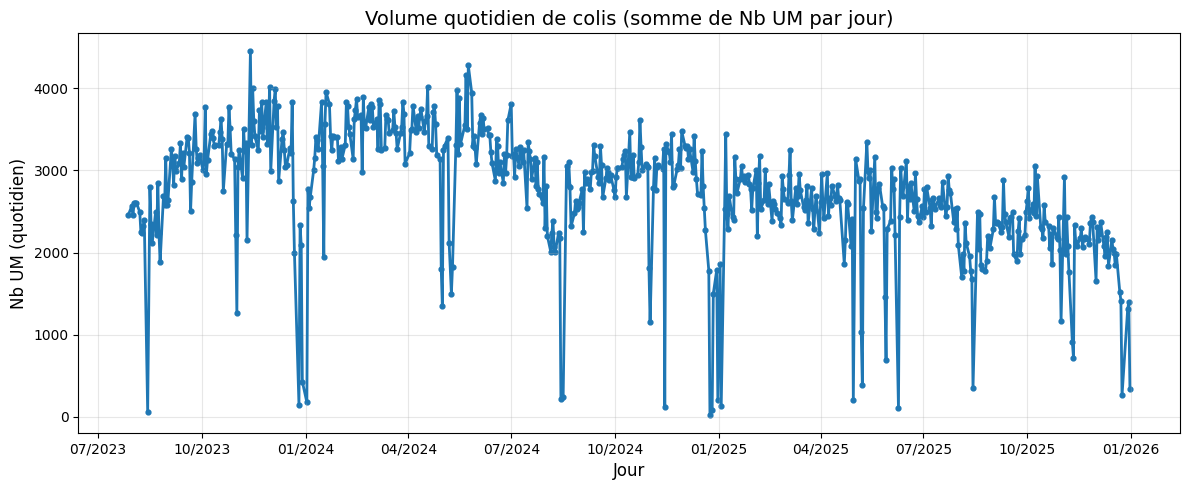

In [27]:
import matplotlib.pyplot as plt
from matplotlib.dates import AutoDateLocator, AutoDateFormatter


# -------------------------
# Tracé du graphique
# -------------------------
plt.figure(figsize=(12, 5))

# Courbe
plt.plot(daily_packages_18.index, daily_packages_18.values, color="#1f77b4", linewidth=2)

# Titre et axes (en français)
plt.title("Volume quotidien de colis (somme de Nb UM par jour)", fontsize=14)
plt.xlabel("Jour", fontsize=12)
plt.ylabel("Nb UM (quotidien)", fontsize=12)

# Mise en forme des dates sur l’axe X
locator = AutoDateLocator()
formatter = AutoDateFormatter(locator)
formatter.scaled[1.0] = "%d/%m/%Y"     # jours
formatter.scaled[30.0] = "%m/%Y"       # mois
formatter.scaled[365.0] = "%Y"         # années

ax = plt.gca()
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(formatter)
plt.grid(True, alpha=0.3)

# Option: points sur la courbe pour faciliter la lecture
plt.scatter(daily_packages_18.index, daily_packages_18.values, color="#1f77b4", s=12)

plt.tight_layout()



In [28]:
daily_packages_18=daily_packages_18.sort_index(ascending = False)
daily_packages_25=daily_packages_25.sort_index(ascending = False)

In [29]:
daily_packages_18.head(50)

warehouse_day
2025-12-31     335.0
2025-12-30    1398.0
2025-12-29    1311.0
2025-12-24     261.0
2025-12-23    1415.0
2025-12-22    1523.0
2025-12-19    1979.0
2025-12-18    1845.0
2025-12-17    1999.0
2025-12-16    2043.0
2025-12-15    2151.0
2025-12-12    1837.0
2025-12-11    2245.0
2025-12-10    2187.0
2025-12-09    1958.0
2025-12-08    2075.0
2025-12-05    2375.0
2025-12-04    2222.0
2025-12-03    2149.0
2025-12-02    2307.0
2025-12-01    1657.0
2025-11-28    2371.0
2025-11-27    2429.0
2025-11-26    2356.0
2025-11-25    2100.0
2025-11-24    2169.0
2025-11-21    2190.0
2025-11-20    2159.0
2025-11-19    2062.0
2025-11-18    2294.0
2025-11-17    2174.0
2025-11-14    2085.0
2025-11-13    2129.0
2025-11-12    2334.0
2025-11-11     719.0
2025-11-10     910.0
2025-11-07    1761.0
2025-11-06    2078.0
2025-11-05    2429.0
2025-11-04    1982.0
2025-11-03    2920.0
2025-10-31    1164.0
2025-10-30    2036.0
2025-10-29    2433.0
2025-10-28    2160.0
2025-10-27    2194.0
2025-10-24    2301.0

In [30]:
daily_packages_25.head(50)

warehouse_day
2025-12-31     250.0
2025-12-30    1481.0
2025-12-29     539.0
2025-12-24     997.0
2025-12-23    1435.0
2025-12-22    1489.0
2025-12-19    1488.0
2025-12-18    2185.0
2025-12-17    2111.0
2025-12-16    1358.0
2025-12-15    1962.0
2025-12-12    1858.0
2025-12-11    2607.0
2025-12-10    2501.0
2025-12-09    1790.0
2025-12-08    2240.0
2025-12-05    2345.0
2025-12-04    2204.0
2025-12-03    1879.0
2025-12-02    2559.0
2025-12-01    1671.0
2025-11-28    2333.0
2025-11-27    2493.0
2025-11-26    2228.0
2025-11-25    2264.0
2025-11-24    2017.0
2025-11-21    2245.0
2025-11-20    2243.0
2025-11-19    1956.0
2025-11-18    2235.0
2025-11-17    2160.0
2025-11-14    2261.0
2025-11-13    2218.0
2025-11-12    2072.0
2025-11-11     748.0
2025-11-10    1349.0
2025-11-07    1641.0
2025-11-06    2016.0
2025-11-05    2457.0
2025-11-04    2038.0
2025-11-03    2808.0
2025-10-31    1086.0
2025-10-30    2098.0
2025-10-29    2465.0
2025-10-28    2022.0
2025-10-27    1994.0
2025-10-24    2372.0

In [31]:
# Then apply your date filter:
threshold = pd.Timestamp("2024-06-10")

voyage_agg1 = voyage_agg[voyage_agg['warehouse_day'] >= threshold]
to_add = voyage_agg_18[voyage_agg_18['warehouse_day'] < threshold]
voyage_agg1 = pd.concat([voyage_agg, to_add])
voyage_agg1.to_csv("voyage_agg.csv", index=False)


In [32]:
voyage_agg1[voyage_agg1['warehouse_day'].dt.year==2025].head()

,N° de voyage,earliest_ts,total_nb_um,warehouse_day
5768,T0012422408,2025-01-02 15:15:00,34.0,2025-01-02
5780,T0012422443,2025-01-02 14:45:00,132.0,2025-01-02
5787,T0012422572,2025-01-02 22:37:00,62.0,2025-01-02
5788,T0012422581,2025-01-02 22:37:00,28.0,2025-01-02
5789,T0012422583,2025-01-02 07:13:00,70.0,2025-01-02


In [33]:
voyage_agg[voyage_agg['warehouse_day'].dt.year==2025].head()

,N° de voyage,earliest_ts,total_nb_um,warehouse_day
5768,T0012422408,2025-01-02 15:15:00,34.0,2025-01-02
5780,T0012422443,2025-01-02 14:45:00,132.0,2025-01-02
5787,T0012422572,2025-01-02 22:37:00,62.0,2025-01-02
5788,T0012422581,2025-01-02 22:37:00,28.0,2025-01-02
5789,T0012422583,2025-01-02 07:13:00,70.0,2025-01-02


In [34]:
# Then apply your date filter:
threshold = pd.Timestamp("2024-06-10")
daily_packages_25.index = pd.to_datetime(daily_packages_25.index)
daily_packages_18.index = pd.to_datetime(daily_packages_18.index)

daily_packages_25 = daily_packages_25[daily_packages_25.index >= threshold]
to_add = daily_packages_18[daily_packages_18.index < threshold]
final = pd.concat([daily_packages_25, to_add])


In [35]:
daily_packages_25.head(50)

warehouse_day
2025-12-31     250.0
2025-12-30    1481.0
2025-12-29     539.0
2025-12-24     997.0
2025-12-23    1435.0
2025-12-22    1489.0
2025-12-19    1488.0
2025-12-18    2185.0
2025-12-17    2111.0
2025-12-16    1358.0
2025-12-15    1962.0
2025-12-12    1858.0
2025-12-11    2607.0
2025-12-10    2501.0
2025-12-09    1790.0
2025-12-08    2240.0
2025-12-05    2345.0
2025-12-04    2204.0
2025-12-03    1879.0
2025-12-02    2559.0
2025-12-01    1671.0
2025-11-28    2333.0
2025-11-27    2493.0
2025-11-26    2228.0
2025-11-25    2264.0
2025-11-24    2017.0
2025-11-21    2245.0
2025-11-20    2243.0
2025-11-19    1956.0
2025-11-18    2235.0
2025-11-17    2160.0
2025-11-14    2261.0
2025-11-13    2218.0
2025-11-12    2072.0
2025-11-11     748.0
2025-11-10    1349.0
2025-11-07    1641.0
2025-11-06    2016.0
2025-11-05    2457.0
2025-11-04    2038.0
2025-11-03    2808.0
2025-10-31    1086.0
2025-10-30    2098.0
2025-10-29    2465.0
2025-10-28    2022.0
2025-10-27    1994.0
2025-10-24    2372.0

In [36]:

import pandas as pd

s = final.copy()
s.index = pd.to_datetime(s.index)
s = s.sort_index()   # ensure chronological order

# ---- Fold Saturdays: add to previous row ----
sat_mask = s.index.dayofweek == 5    # Saturdays
sat_positions = [s.index.get_loc(d) for d in s.index[sat_mask]]

for pos in sat_positions:
    if pos > 0:  # ensure there *is* a previous row
        s.iloc[pos - 1] += s.iloc[pos]   # add Saturday to previous row

# remove Saturdays
s = s[~sat_mask]

# ---- Fold Sundays: add to next row ----
sun_mask = s.index.dayofweek == 6    # Sundays
sun_positions = [s.index.get_loc(d) for d in s.index[sun_mask]]

# careful: iterate in reverse so shifting index doesn't affect upcoming positions
for pos in reversed(sun_positions):
    if pos < len(s) - 1:  # ensure there is a next row
        s.iloc[pos + 1] += s.iloc[pos]   # add Sunday to next row

# remove Sundays
s = s[~sun_mask]

## final sorted series
final = s.sort_index(ascending=False)



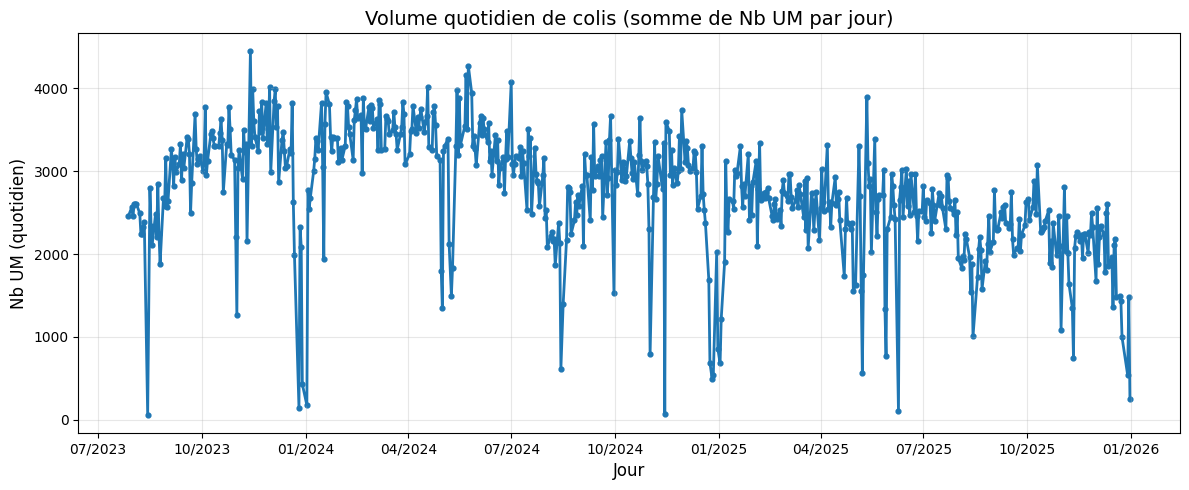

In [37]:
# -------------------------
# Tracé du graphique
# -------------------------
plt.figure(figsize=(12, 5))

# Courbe
plt.plot(final.index, final.values, color="#1f77b4", linewidth=2)

# Titre et axes (en français)
plt.title("Volume quotidien de colis (somme de Nb UM par jour)", fontsize=14)
plt.xlabel("Jour", fontsize=12)
plt.ylabel("Nb UM (quotidien)", fontsize=12)

# Mise en forme des dates sur l’axe X
locator = AutoDateLocator()
formatter = AutoDateFormatter(locator)
formatter.scaled[1.0] = "%d/%m/%Y"     # jours
formatter.scaled[30.0] = "%m/%Y"       # mois
formatter.scaled[365.0] = "%Y"         # années

ax = plt.gca()
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(formatter)
plt.grid(True, alpha=0.3)

# Option: points sur la courbe pour faciliter la lecture
plt.scatter(final.index, final.values, color="#1f77b4", s=12)

plt.tight_layout()



In [38]:
daily_packages_25[daily_packages_25<1100]

warehouse_day
2025-12-31     250.0
2025-12-29     539.0
2025-12-24     997.0
2025-11-11     748.0
2025-10-31    1086.0
2025-08-14    1007.0
2025-06-09     102.0
2025-05-29     766.0
2025-05-08     563.0
2025-01-02     680.0
2024-12-31     859.0
2024-12-27     536.0
2024-12-26     489.0
2024-12-24     690.0
2024-11-14      72.0
2024-11-01     789.0
2024-08-14     617.0
Name: total_nb_um, dtype: float64

In [39]:
final.head()

warehouse_day
2025-12-31     250.0
2025-12-30    1481.0
2025-12-29     539.0
2025-12-24     997.0
2025-12-23    1435.0
Name: total_nb_um, dtype: float64

In [40]:
final.to_frame(name="total_nb_um")

,total_nb_um
warehouse_day,
2025-12-31,250.0
2025-12-30,1481.0
2025-12-29,539.0
2025-12-24,997.0
2025-12-23,1435.0
...,...
2023-08-03,2607.0
2023-08-02,2604.0
2023-08-01,2455.0


In [41]:

final.to_frame(name="total_nb_um") \
                 .reset_index() \
                 .rename(columns={"index": "warehouse_day"})


,warehouse_day,total_nb_um
0,2025-12-31,250.0
1,2025-12-30,1481.0
2,2025-12-29,539.0
3,2025-12-24,997.0
4,2025-12-23,1435.0
...,...,...
613,2023-08-03,2607.0
614,2023-08-02,2604.0
615,2023-08-01,2455.0
616,2023-07-31,2569.0


In [42]:
final.to_frame(name="total_nb_um") \
                 .reset_index() \
                 .rename(columns={"index": "warehouse_day"}) \
                 .to_csv("daily_packages_25.csv", index=False)
